<a href="https://colab.research.google.com/github/simulate111/Acquisition-and-Analysis-of-Biosignals/blob/main/dtek0042_exercise_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DTEK0042 Exercise 2

        Name:
        Email:

*** Note for Google Colab Users ***
     Because Google Colab doesn't have a button to convert your notebook to .html format here is a quick work around:
   1. open a new google colab notebook
   2. in the files section in google colab, upload the .ipynb file you want to be converted to .html
   3. in your new open notebook run this command in an empty cell: !jupyter nbconvert --to html YourFileName.ipynb
   4. after the command is finished running refresh the page
   5. In your files section you should see your original .ipynb file that you uploaded and then a .html file of that same notebook.
   6. download the .html file and you're good to go!

In this exercise, you are required to analyze an ECG signal step-by-step as outlined below. The deliverables for this exercise are a jupyter notebook in both .ipynb and .html format. Please provide caption for every figure and include description for every figure.

## library Imports

In [1]:
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt

# Data Import and plotting
* Import the ECG signal named “ECG_800Hz.txt” into your python environment and store it in a variable named “ECG_sig”.
* Plot the signal
* Note: the sampling frequency of this signal is 800Hz.
* You need this value if you want to plot ECG versus time.


     HINT: ECG_sig = np.loadtxt(the directory of the ECG signal)
     https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html

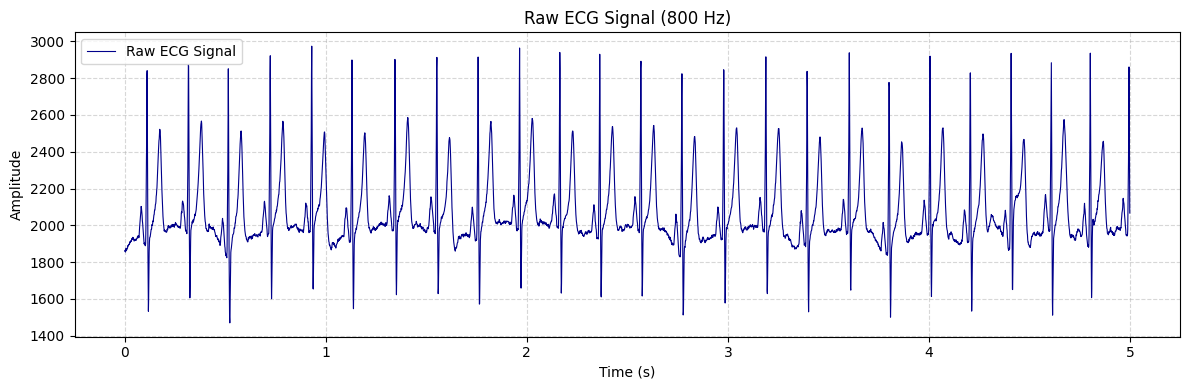

In [2]:
#code

# --- ADDED CODE START ---
# Loading the raw ECG signal from the file path provided in the directory.
#ECG_sig = np.loadtxt('/content/ECG_800hz.txt')
ECG_sig = np.loadtxt('https://raw.githubusercontent.com/simulate111/Acquisition-and-Analysis-of-Biosignals/refs/heads/main/ECG1.dat.txt')

# Defining sample frequency and calculating the time axis
fs = 800
time = np.arange(len(ECG_sig)) / fs

# Plotting the ECG signal versus time
plt.figure(figsize=(12, 4))
plt.plot(time, ECG_sig, label='Raw ECG Signal', color='darkblue', linewidth=0.8)
plt.title('Raw ECG Signal (800 Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
# --- ADDED CODE END ---

**Figure 1.** Original ECG signal sampled at 800 Hz, plotted as a function of time.

# Discrete Fourier Transform

 * Compute DFT using FFT algorithm provided by scipy package. Take only the positive frequencies from the computed DFT and subsequently calculate the magnitude (absolute value) of frequency content. Plot the calculated magnitude versus frequency.
 * Discard the frequencies below 0.5Hz and above 40Hz and replot the magnitude versus frequency.


     * HINT use scipy.fft.rfft() outputs positive portion of function
     
     https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.rfft.html
     https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.rfftfreq.html
     

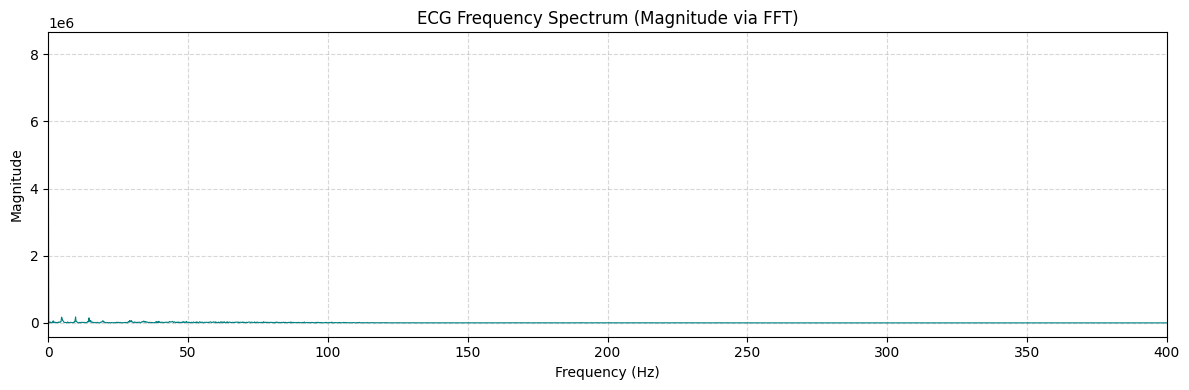

In [3]:
# code

# --- ADDED CODE START ---
import scipy.fft

# Computing the Discrete Fourier Transform
dft_output = scipy.fft.rfft(ECG_sig)
freqs = scipy.fft.rfftfreq(len(ECG_sig), d=1/fs)
magnitude = np.abs(dft_output)

# Plotting full positive frequency spectrum
plt.figure(figsize=(12, 4))
plt.plot(freqs, magnitude, color='teal', linewidth=0.8)
plt.xlim(0, 400)
plt.title('ECG Frequency Spectrum (Magnitude via FFT)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Figure 2.** Magnitude of the positive-frequency components of the ECG signal from 0 to 400 Hz obtained using the real-valued FFT.

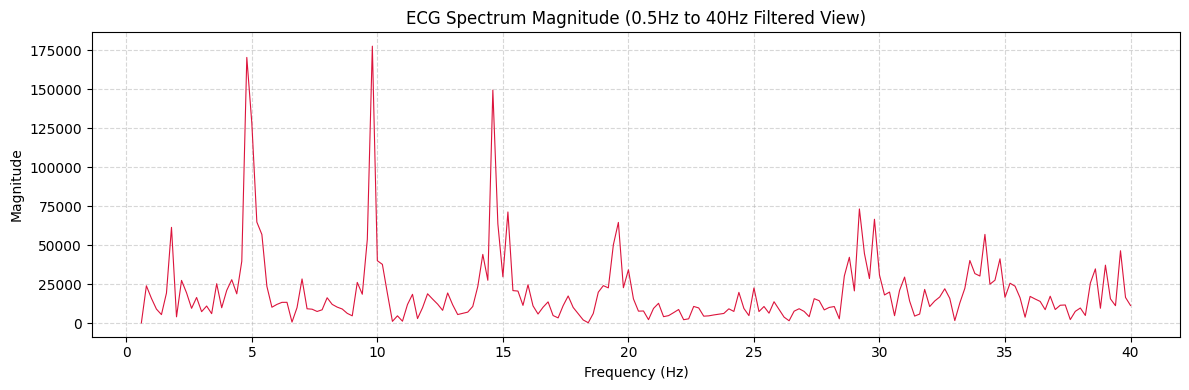

In [4]:
# Filtering frequencies below 0.5Hz and above 40Hz for visualization
mask = (freqs >= 0.5) & (freqs <= 40)
filtered_freqs = freqs[mask]
filtered_magnitude = magnitude[mask]

# Plotting magnitude within [0.5Hz - 40Hz] range
plt.figure(figsize=(12, 4))
plt.plot(filtered_freqs, filtered_magnitude, color='crimson', linewidth=0.8)
plt.title('ECG Spectrum Magnitude (0.5Hz to 40Hz Filtered View)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
# --- ADDED CODE END ---

**Figure 3.** Magnitude of the ECG frequency spectrum between 0.5 and 40 Hz.

# Band Pass Filter Design
*  Design a band pass filter. Use Butterworth filter of order 4 with cutoff frequencies equal to 0.5Hz and 40Hz.


* Design another butterworth band pass filter but this time use an order of 2 with cutoff frequencies equal to 0.5Hz and 40Hz


* Plot the frequency response of both filters and explain your observations


    * Hint use the following three functions scipy.signal.butter() and scipy.signal.freqz()


* Important to use the scipy.signal.freqz() function and NOT the scipy.signal.freqs() function.

        scipy.signal.freqz() is for digital filters which is what we want.

https://docs.scipy.org/doc/scipy/reference/signal.html#filtering link to info about scipy.signal functions

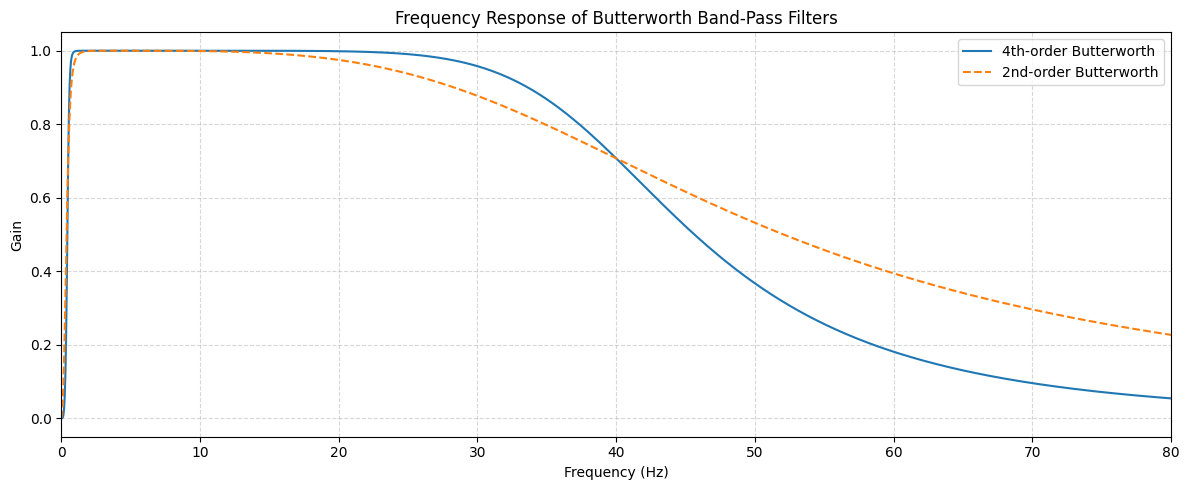

In [5]:
# code

# --- ADDED CODE START ---
import scipy.signal

# 4th-order Butterworth band-pass filter
b4, a4 = scipy.signal.butter(4, [0.5, 40], btype='bandpass', fs=fs)

# 2nd-order Butterworth band-pass filter
b2, a2 = scipy.signal.butter(2, [0.5, 40], btype='bandpass', fs=fs)

# Frequency response
w4, h4 = scipy.signal.freqz(b4, a4, worN=8000)
w2, h2 = scipy.signal.freqz(b2, a2, worN=8000)

# Convert frequency from radians/sample to Hz
freq_hz = w4 * fs / (2 * np.pi)

plt.figure(figsize=(12, 5))
plt.plot(freq_hz, np.abs(h4), label='4th-order Butterworth')
plt.plot(freq_hz, np.abs(h2), label='2nd-order Butterworth', linestyle='--')

plt.xlim(0, 80)
plt.title('Frequency Response of Butterworth Band-Pass Filters')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Gain')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
# --- ADDED CODE END ---

**Figure 4.** Frequency responses of the 2nd-order and 4th-order Butterworth band-pass filters with cutoff frequencies of 0.5 Hz and 40 Hz.

## Observations

The 4th-order Butterworth filter has sharper transitions around the lower and upper cutoff frequencies than the 2nd-order filter. Therefore, the 4th-order filter provides stronger attenuation outside the 0.5–40 Hz passband. Both filters preserve the frequency range between approximately 0.5 and 40 Hz, while the higher-order filter provides a steeper transition between the passband and stopband.

# Apply filter to ECG_Sig
* Use the designed 4th order filter to filter ECG_sig and plot the first 5000 samples from the original signal (raw_signal) and the filtered signal.
* What happens after filtering?
* Explain your observations

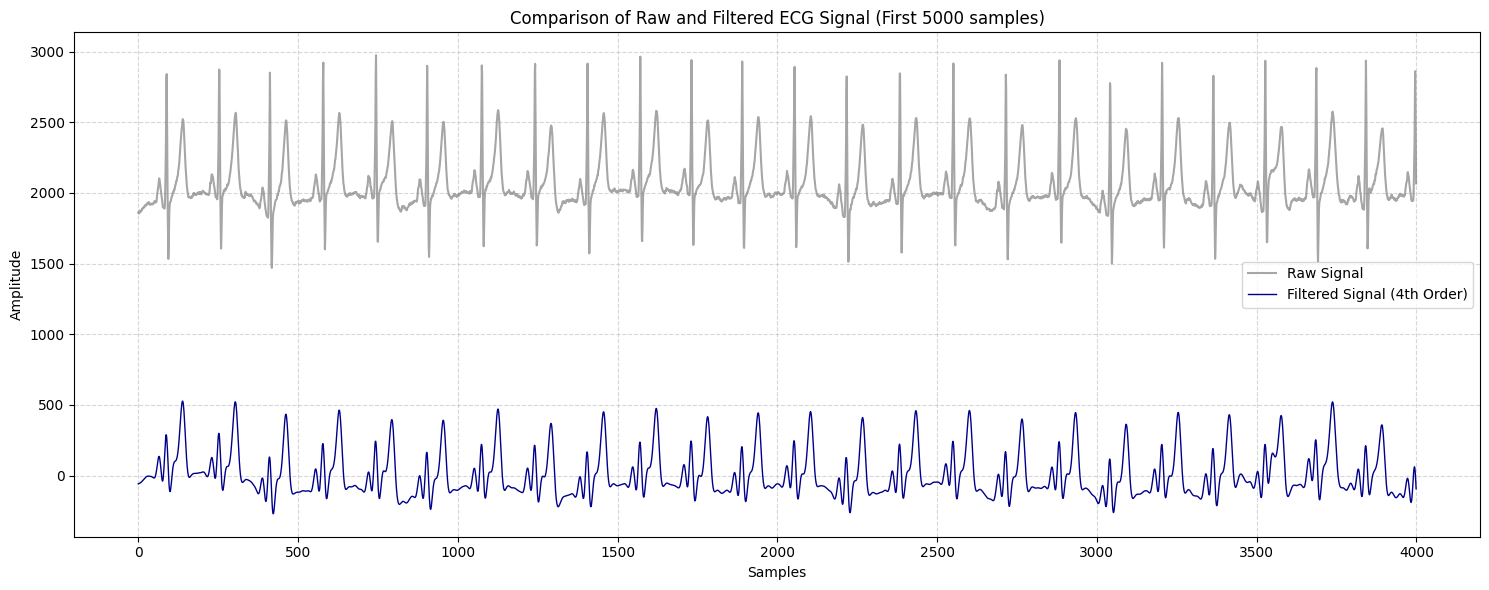

In [6]:
#code

# --- ADDED CODE START ---
# Apply the 4th order filter to ECG_sig
filtered_ECG = scipy.signal.filtfilt(b4, a4, ECG_sig)

# Plotting the first 5000 samples comparison
plt.figure(figsize=(15, 6))
plt.plot(ECG_sig[:5000], label='Raw Signal', color='gray', alpha=0.7)
plt.plot(filtered_ECG[:5000], label='Filtered Signal (4th Order)', color='darkblue', linewidth=1)
plt.title('Comparison of Raw and Filtered ECG Signal (First 5000 samples)')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
# --- ADDED CODE END ---

**Figure 5.** Comparison of the original and filtered ECG signals for the first 5000 samples using the 4th-order Butterworth band-pass filter.

## Observations

The 4th-order band-pass filter reduces the low-frequency baseline wander visible in the raw ECG signal. It also attenuates high-frequency components outside the selected passband, resulting in a smoother ECG waveform. The main ECG features, including the QRS complexes, become more clearly visible after filtering.

# Plot the frequency domain of raw and filtered signal
* Plot raw and filtered signals in the frequency domain and explain your observations
* For each signal select frequencies from 0 to 50Hz

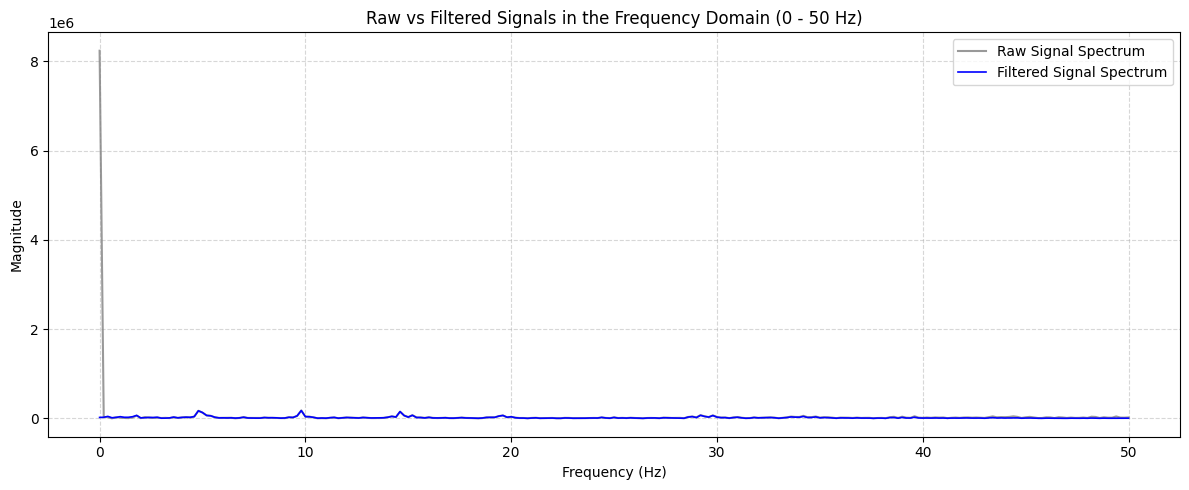

In [7]:
#code

# --- ADDED CODE START ---
# Compute FFT of raw signal
raw_dft = scipy.fft.rfft(ECG_sig)
raw_freqs = scipy.fft.rfftfreq(len(ECG_sig), d=1/fs)
raw_mag = np.abs(raw_dft)

# Compute FFT of filtered signal
filt_dft = scipy.fft.rfft(filtered_ECG)
filt_freqs = scipy.fft.rfftfreq(len(filtered_ECG), d=1/fs)
filt_mag = np.abs(filt_dft)

# Filter to range 0 to 50 Hz
raw_mask = (raw_freqs >= 0) & (raw_freqs <= 50)
filt_mask = (filt_freqs >= 0) & (filt_freqs <= 50)

# Plotting raw and filtered signal spectra in the 0-50Hz frequency range
plt.figure(figsize=(12, 5))
plt.plot(raw_freqs[raw_mask], raw_mag[raw_mask], label='Raw Signal Spectrum', color='gray', alpha=0.8)
plt.plot(filt_freqs[filt_mask], filt_mag[filt_mask], label='Filtered Signal Spectrum', color='blue', linewidth=1.2)
plt.title('Raw vs Filtered Signals in the Frequency Domain (0 - 50 Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
# --- ADDED CODE END ---

**Figure 6.** Frequency-domain magnitude spectra of the raw and filtered ECG signals between 0 and 50 Hz.

## Observations:
* **DC and Low Frequency Removal:** In the raw spectrum, there is a massive spike close to 0 Hz representing baseline wander. The filtered spectrum is strongly attenuated below 0.5 Hz.
* **High-Frequency Cutoff:** The magnitude drops off significantly as the frequency approaches and crosses 40 Hz, showing that high-frequency noise has been successfully attenuated.

# QRS Detection
*  QRS detection using “hamilton” method provided by the “biosppy” package.
*  If you do not have this package installed, use the following command to install it  !pip install biosppy in the next cell
* For google colab use following command in the cell as well: !pip install biosppy


In [8]:
#still need to locally install biosppy
#code
# --- ADDED CODE START ---
!pip install peakutils biosppy
# --- ADDED CODE END ---
import biosppy.signals.ecg
#from biosppy.signals import ecg

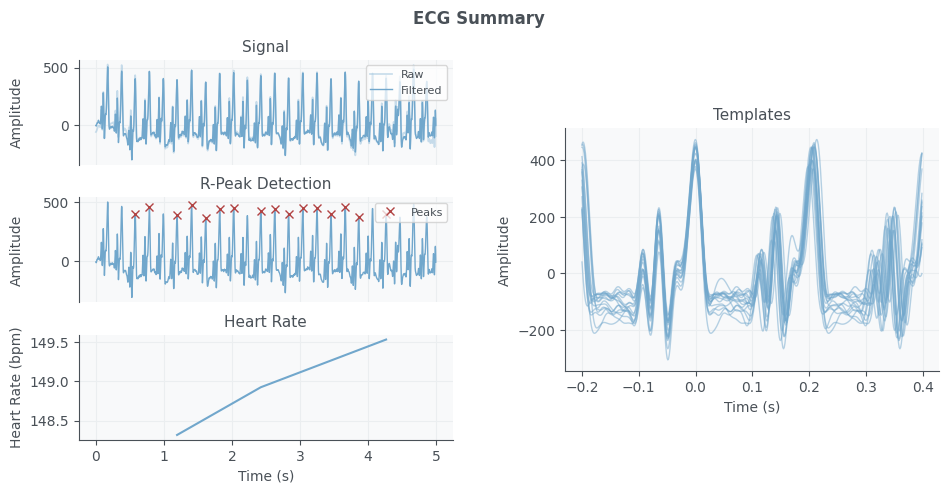

In [9]:
# --- ADDED CODE START ---
# Performing QRS detection using "hamilton" method on the filtered ECG signal
out = biosppy.signals.ecg.ecg(signal=filtered_ECG, sampling_rate=fs, show=True)
# --- ADDED CODE END ---

**Figure 7.** QRS detection of the filtered ECG signal using the Hamilton method implemented in BioSPPy.

## Observations

The BioSPPy ECG processing identifies the main R-peaks in the filtered ECG signal using the Hamilton method. The detected peaks generally correspond to the prominent QRS complexes in the filtered waveform. The preprocessing and band-pass filtering make the QRS complexes more distinct and facilitate their detection.